### Author :  Abhipsa Acharya

# Trigger Efficiency Study — UL Run 2
## Boosted + Resolved All-Hadronic $t\bar{t}$

Using centrally produced TTToHadronic NanoAODv9 accessed via XRootD from cmslpc.  
Triggers matched to the **JetHT** primary dataset.  

In [1]:
import subprocess
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import mplhep as hep
plt.style.use(hep.style.CMS)

%matplotlib inline
print('Ready')

/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-pac

Ready


## 1. Era configuration
Change `ERA` to switch between years. Dataset paths and luminosities will be update automatically.

In [2]:
# CHANGE THIS TO SWITCH ERAS                         

ERA = "UL2018"    # Options: "UL2016preVFP", "UL2016postVFP", "UL2017", "UL2018",
                  #          "Run3_2022", "Run3_2022EE", "Run3_2023", "Run3_2023BPix"
N_FILES = 3

DATASETS = {
    # Run 2 UL (powheg, NanoAODv9)
    "UL2016preVFP":  "/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/RunIISummer20UL16NanoAODAPVv9-106X_mcRun2_asymptotic_preVFP_v11-v1/NANOAODSIM",
    "UL2016postVFP": "/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v1/NANOAODSIM",
    "UL2017":        "/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/RunIISummer20UL17NanoAODv9-106X_mc2017_realistic_v9-v1/NANOAODSIM",
    "UL2018":        "/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM",
    # Run 3 2022 (amcatnloFXFX, NanoAODv12)
    "Run3_2022":     "/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer22NanoAODv12-130X_mcRun3_2022_realistic_v5-v1/NANOAODSIM",
    "Run3_2022EE":   "/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer22EENanoAODv12-130X_mcRun3_2022_realistic_postEE_v6-v3/NANOAODSIM",
    # Run 3 2023 (amcatnloFXFX, NanoAODv12)
    "Run3_2023":     "/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer23NanoAODv12-130X_mcRun3_2023_realistic_v14-v3/NANOAODSIM",
    "Run3_2023BPix": "/TTto4Q-2Jets_TuneCP5_13p6TeV_amcatnloFXFX-pythia8/Run3Summer23BPixNanoAODv12-130X_mcRun3_2023_realistic_postBPix_v2-v2/NANOAODSIM",
}

LUMIS = {
    "UL2016preVFP":  "19.5 fb$^{-1}$",
    "UL2016postVFP": "16.8 fb$^{-1}$",
    "UL2017":        "41.5 fb$^{-1}$",
    "UL2018":        "59.7 fb$^{-1}$",
    "Run3_2022":     "7.9 fb$^{-1}$",
    "Run3_2022EE":   "26.7 fb$^{-1}$",
    "Run3_2023":     "17.8 fb$^{-1}$",
    "Run3_2023BPix": "9.5 fb$^{-1}$",
}

ENERGY = "13 TeV" if ERA.startswith("UL") else "13.6 TeV"
DATASET = DATASETS[ERA]
LUMI_TEXT = LUMIS[ERA] + f" ({ENERGY})"
print(f"Era: {ERA}")
print(f"Dataset: {DATASET}")

Era: UL2018
Dataset: /TTToHadronic_TuneCP5_13TeV-powheg-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM


## 2. Query DAS and open files via XRootD
Using multiple files for better statistics in the turn-on tails.

In [3]:
# Query DAS — if wildcard needed, fall back
print(f"Querying DAS for {N_FILES} files...")
r = subprocess.run(
    ["dasgoclient", "-query", f"file dataset={DATASET}", "-limit", str(N_FILES)],
    capture_output=True, text=True, timeout=120
)
fnames = [f.strip() for f in r.stdout.strip().split('\n') if f.strip()]

# If exact path fails, try wildcard
if not fnames:
    print("Exact path returned 0 files, trying wildcard...")
    parts = DATASET.split("/")
    # Replace the campaign tag with wildcard
    wild = "/".join(parts[:3]) + "-*/" + parts[3]
    # First resolve the dataset name
    r2 = subprocess.run(
        ["dasgoclient", "-query", f"dataset={'/'.join(parts[:3])}-*/{parts[3]}"],
        capture_output=True, text=True, timeout=120
    )
    resolved = [d.strip() for d in r2.stdout.strip().split('\n') if d.strip()]
    if resolved:
        print(f"Resolved to: {resolved[0]}")
        r3 = subprocess.run(
            ["dasgoclient", "-query", f"file dataset={resolved[0]}", "-limit", str(N_FILES)],
            capture_output=True, text=True, timeout=120
        )
        fnames = [f.strip() for f in r3.stdout.strip().split('\n') if f.strip()]

print(f"Got {len(fnames)} files:")
for fn in fnames:
    print(f"  {fn}")

urls = ["root://cmsxrootd.fnal.gov/" + fn for fn in fnames]

Querying DAS for 3 files...
Got 3 files:
  /store/mc/RunIISummer20UL18NanoAODv9/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/270000/0A0C246F-D01B-6F4D-85E6-3A75C27C5197.root
  /store/mc/RunIISummer20UL18NanoAODv9/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/270000/C9AE400A-46AB-4245-B122-B545D4044D85.root
  /store/mc/RunIISummer20UL18NanoAODv9/TTToHadronic_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/270000/05843D24-DAB6-CC4C-BB2B-863C8E57D98D.root


## 3. Discover available triggers
Open the first file to get the branch list, then auto-detect trigger families.

In [4]:
first = uproot.open(urls[0])["Events"]
all_branches = first.keys() #looking for triggers

hlt_all = sorted([b for b in all_branches if b.startswith("HLT_")])
print(f"Branches: {len(all_branches)}, HLT triggers: {len(hlt_all)}")

Branches: 1628, HLT triggers: 651


## 4. Define trigger groups
Only triggers actually present in the file are kept. Groups are organized by physics use case.

### Trigger Categories Used in This Study

In this analysis, the triggers are organized according to the type of event topology they are designed to select. Broadly, they fall into resolved, boosted, inclusive, and flavor-tagged categories.

Resolved triggers are designed for non-boosted topologies where decay products are well separated and reconstructed as multiple individual AK4 jets. These typically rely on jet multiplicity and moderate transverse momentum thresholds. They are relevant when the top quark decay products are spatially resolved and not merged.

Boosted triggers target high transverse momentum regimes where decay products become collimated. In this case, large-radius (AK8) jets are used to capture merged hadronic activity from heavy particle decays. These triggers are particularly important for boosted topologies and are expected to turn on as the leading fat jet pT increases.

Inclusive triggers are based on global event activity, most commonly the scalar sum of jet transverse momenta (HT). They do not depend strongly on detailed substructure but instead require the event to pass an overall energy scale threshold. These are useful for broadly capturing hadronic events.

Flavor-tagged triggers introduce additional b-tagging requirements at the HLT level. In these cases, efficiency depends not only on kinematic thresholds but also on the performance of online flavor identification algorithms. Their behavior reflects both energy scale effects and tagging efficiency.


In [5]:
def keep(trig_list):
    return [t for t in trig_list if t in hlt_all]

# GROUP 1: AK8 PFHT + TrimMass (boosted, unprescaled only)
# AK8PFHT750 is prescaled (1.4 fb-1) — excluded
boosted_ak8ht = keep([
    "HLT_AK8PFHT800_TrimMass50",   # 59.8 fb-1
    "HLT_AK8PFHT850_TrimMass50",   # 59.8
    "HLT_AK8PFHT900_TrimMass50",   # 59.8
])

# GROUP 2: AK8 single jet + TrimMass (boosted, unprescaled only)
# AK8PFJet360 and 380 are prescaled (1.4 fb-1) — excluded
boosted_ak8jet_trim = keep([
    "HLT_AK8PFJet400_TrimMass30",  # 59.8 fb-1
    "HLT_AK8PFJet420_TrimMass30",  # 59.8
])

# GROUP 3: AK8 pure high-pT (boosted)
# AK8PFJet400/450 do NOT exist in 2018 unprescaled menu
boosted_ak8jet_pt = keep([
    "HLT_AK8PFJet500",             # 59.8 fb-1
    "HLT_AK8PFJet550",             # 59.8
])

# GROUP 3b: AK8 + b-tag (boosted)
boosted_ak8_btag = keep([
    "HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p17",   # 59.8 fb-1
    "HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p1",    # 59.8
    "HLT_AK8PFJet330_TrimMass30_PFAK8BoostedDoubleB_p02", # 59.8
    "HLT_AK8PFJet330_TrimMass30_PFAK8BoostedDoubleB_np4", # 59.8
])

# GROUP 4: SixPFJet (resolved, all have btag in 2018)
resolved_sixjet = keep([
    "HLT_PFHT380_SixPFJet32_DoublePFBTagDeepCSV_2p2",       # 17.7 fb-1
    "HLT_PFHT400_SixPFJet32_DoublePFBTagDeepCSV_2p94",      # 42.1
    "HLT_PFHT430_SixPFJet40_PFBTagDeepCSV_1p5",             # 12.4
    "HLT_PFHT450_SixPFJet36_PFBTagDeepCSV_1p59",            # 42.1
])

# GROUP 5: QuadPFJet (resolved, all have btag in 2018)
resolved_quadjet = keep([
    "HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepCSV_4p5",  # 59.8 fb-1
    "HLT_QuadPFJet103_88_75_15_DoublePFBTagDeepCSV_1p3_7p7_VBF1",    # 54.5
    "HLT_QuadPFJet111_90_80_15_DoublePFBTagDeepCSV_1p3_7p7_VBF1",    # 54.5
    "HLT_QuadPFJet103_88_75_15_PFBTagDeepCSV_1p3_VBF2",              # 54.5
    "HLT_QuadPFJet105_88_76_15_PFBTagDeepCSV_1p3_VBF2",              # 54.5
    "HLT_QuadPFJet111_90_80_15_PFBTagDeepCSV_1p3_VBF2",              # 54.5
])

# GROUP 6: FivePFJet (resolved, btag required)
resolved_fivejet = keep([
    "HLT_PFHT400_FivePFJet_100_100_60_30_30_DoublePFBTagDeepCSV_4p5",  # 12.8 fb-1
    "HLT_PFHT400_FivePFJet_120_120_60_30_30_DoublePFBTagDeepCSV_4p5",  # 12.8
])

# GROUP 7: Inclusive PFHT (only PFHT1050 is unprescaled)
inclusive_pfht = keep([
    "HLT_PFHT1050",                # 59.8 fb-1
])

all_groups = [
    ("Boosted AK8 HT+TrimMass",    boosted_ak8ht),
    ("Boosted AK8 Jet+TrimMass",   boosted_ak8jet_trim),
    ("Boosted AK8 Jet pure pT",    boosted_ak8jet_pt),
    ("Boosted AK8 + b-tag",        boosted_ak8_btag),
    ("Resolved SixPFJet",          resolved_sixjet),
    ("Resolved QuadPFJet",         resolved_quadjet),
    ("Resolved FivePFJet",         resolved_fivejet),
    ("Inclusive PFHT",             inclusive_pfht),
]

all_triggers = []
for name, trigs in all_groups:
    print(f"{name} ({len(trigs)}):")
    for t in trigs:
        print(f"  {t}")
    all_triggers.extend(trigs)
print(f"\nTotal: {len(all_triggers)} triggers")

Boosted AK8 HT+TrimMass (3):
  HLT_AK8PFHT800_TrimMass50
  HLT_AK8PFHT850_TrimMass50
  HLT_AK8PFHT900_TrimMass50
Boosted AK8 Jet+TrimMass (2):
  HLT_AK8PFJet400_TrimMass30
  HLT_AK8PFJet420_TrimMass30
Boosted AK8 Jet pure pT (2):
  HLT_AK8PFJet500
  HLT_AK8PFJet550
Boosted AK8 + b-tag (4):
  HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p17
  HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p1
  HLT_AK8PFJet330_TrimMass30_PFAK8BoostedDoubleB_p02
  HLT_AK8PFJet330_TrimMass30_PFAK8BoostedDoubleB_np4
Resolved SixPFJet (2):
  HLT_PFHT400_SixPFJet32_DoublePFBTagDeepCSV_2p94
  HLT_PFHT450_SixPFJet36_PFBTagDeepCSV_1p59
Resolved QuadPFJet (6):
  HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTagDeepCSV_4p5
  HLT_QuadPFJet103_88_75_15_DoublePFBTagDeepCSV_1p3_7p7_VBF1
  HLT_QuadPFJet111_90_80_15_DoublePFBTagDeepCSV_1p3_7p7_VBF1
  HLT_QuadPFJet103_88_75_15_PFBTagDeepCSV_1p3_VBF2
  HLT_QuadPFJet105_88_76_15_PFBTagDeepCSV_1p3_VBF2
  HLT_QuadPFJet111_90_80_15_PFBTagDeepCSV_1p3_VBF2
Resolved FivePFJet (0):


## 5. Bulk load from all files
All branches read in one call per file, then concatenated.

### Load files via XRootD (with retry logic)

NanoAOD files are stored across distributed storage nodes accessed via the XRootD
protocol through the CMS AAA (Any Data, Anytime, Anywhere) federation.
Occasionally a file will **timeout** — this means the specific storage node hosting
that file is slow, overloaded, or temporarily down.

As documented in the [CMS XRootD Remote File Access TWiki](https://twiki.cern.ch/twiki/bin/view/CMSPublic/XRootDRemoteFileAccess),
the `[ERROR] Operation expired` error is transient and **retry is the recommended solution**.
The [CMS XRootD Architecture](https://twiki.cern.ch/twiki/bin/view/Main/CmsXrootdArchitecture)
design principle states that "failures should be caught as early as possible and I/O
retried or rerouted to a different site."

**Strategy:** We query DAS for 10 file candidates but only need 3. If a file times out,
we skip it and try the next one. This is standard practice at cmslpc — the same file
may work fine an hour later when the node recovers.

Common XRootD errors:
- `[ERROR] Operation expired` → storage node timeout (most common, just skip)
- `[ERROR] Permission denied` → expired VOMS proxy, run `voms-proxy-init --voms cms`
- `[ERROR] No such file` → file was moved/deleted, re-query DAS

In [6]:
import time

# Get more files than needed so we can skip bad ones
print("Querying DAS for 10 files...")
r = subprocess.run(
    ["dasgoclient", "-query", f"file dataset={DATASET}", "-limit", "10"],
    capture_output=True, text=True, timeout=60
)
fnames = [f.strip() for f in r.stdout.strip().split('\n') if f.strip()]
print(f"Got {len(fnames)} candidates")

branches_to_load = [
    "FatJet_pt", "FatJet_eta", "FatJet_mass", "FatJet_msoftdrop",
    "Jet_pt", "Jet_eta",
    "GenPart_pt", "GenPart_eta", "GenPart_pdgId", "GenPart_status",
] + all_triggers

chunks = []
for i, fn in enumerate(fnames):
    if len(chunks) >= N_FILES:
        break
    url = "root://cmsxrootd.fnal.gov/" + fn
    print(f"Trying file {i+1}: {fn.split('/')[-1]}...", end=" ")
    try:
        ev = uproot.open(url, timeout=120)["Events"]
        chunk = ev.arrays(branches_to_load, library="ak")
        print(f"OK, {len(chunk)} events")
        chunks.append(chunk)
    except Exception as e:
        print(f"SKIP ({e.__class__.__name__})")
        continue

data = ak.concatenate(chunks)
N = len(data)
print(f"\nLoaded {len(chunks)} files, {N} total events")

Querying DAS for 10 files...
Got 10 candidates
Trying file 1: 0A0C246F-D01B-6F4D-85E6-3A75C27C5197.root... OK, 868000 events
Trying file 2: C9AE400A-46AB-4245-B122-B545D4044D85.root... OK, 1006000 events
Trying file 3: 05843D24-DAB6-CC4C-BB2B-863C8E57D98D.root... OK, 1320000 events

Loaded 3 files, 3194000 total events


## 6. Build kinematic variables — sanity checks

These printouts verify the data loaded correctly and characterize the phase space:

- **FatJet multiplicity:** Only ~27% of inclusive $t\bar{t}$ events produce a
  reconstructed AK8 jet (NanoAOD threshold $p_T > 170$ GeV), and ~12% have two —
  reflecting the rarity of fully-boosted topologies in an unfiltered sample.
  These fractions define the effective denominator for boosted trigger efficiencies.
- **Kinematic ranges:** The extreme tails ($p_T > 10$ TeV) are unphysical
  (pileup/reconstruction artifacts) but do not affect the efficiency calculation
  since binning is capped at 1200 GeV ($p_T$) and 2500 GeV ($H_T$).
- **Jet multiplicity 0–16:** Confirms sufficient population across the spectrum
  for resolved multijet trigger studies (SixPFJet requires $\geq 6$ jets).

In [7]:
fj_pt = data["FatJet_pt"]
fj_msoftdrop = data["FatJet_msoftdrop"]
jet_pt = data["Jet_pt"]

has_fj = ak.num(fj_pt) >= 1
has_fj_np = ak.to_numpy(has_fj)
lead_fj_pt = ak.to_numpy(ak.flatten(fj_pt[has_fj][:, 0:1]))
lead_fj_msd = ak.to_numpy(ak.flatten(fj_msoftdrop[has_fj][:, 0:1]))

has_2fj = ak.num(fj_pt) >= 2
has_2fj_np = ak.to_numpy(has_2fj)
sublead_fj_pt = ak.to_numpy(ak.flatten(fj_pt[has_2fj][:, 1:2]))

ak8_ht = ak.to_numpy(ak.sum(fj_pt[fj_pt > 200], axis=1))
ht = ak.to_numpy(ak.sum(jet_pt[jet_pt > 30], axis=1))
njet = ak.to_numpy(ak.num(jet_pt[jet_pt > 30]))

print(f"Events with >= 1 FatJet: {np.sum(has_fj_np)}/{N}")
print(f"Events with >= 2 FatJets: {np.sum(has_2fj_np)}/{N}")
print(f"Lead FatJet pT: {np.min(lead_fj_pt):.0f} - {np.max(lead_fj_pt):.0f} GeV")
print(f"AK4 HT: {np.min(ht):.0f} - {np.max(ht):.0f} GeV")
print(f"Njet(pT>30): {np.min(njet)} - {np.max(njet)}")

Events with >= 1 FatJet: 855771/3194000
Events with >= 2 FatJets: 385309/3194000
Lead FatJet pT: 170 - 25328 GeV
AK4 HT: 0 - 25446 GeV
Njet(pT>30): 0 - 16


## 7. Gen-level sanity check

In [8]:
gen_pdgId = data["GenPart_pdgId"]
gen_status = data["GenPart_status"]
gen_pt = data["GenPart_pt"]
is_top = (abs(gen_pdgId) == 6) & (gen_status == 62)
top_pt = gen_pt[is_top]

print(f"Events with 2 tops: {ak.sum(ak.num(top_pt) == 2)}/{N}")
flat_top = ak.flatten(top_pt)
print(f"Top pT: {ak.min(flat_top):.0f} - {ak.max(flat_top):.0f} GeV, mean={ak.mean(flat_top):.0f} GeV")

Events with 2 tops: 3194000/3194000
Top pT: 0 - 1876 GeV, mean=123 GeV


## 8. Efficiency calculator and plotting tools
Vectorized Clopper-Pearson 68% confidence intervals. The term “vectorized” here simply means that the Clopper–Pearson confidence intervals are computed for all histogram bins at once using arrays, rather than looping over each bin individually. The bin counts (number of passed events and total events per bin) are stored as arrays, and the Beta distribution function is applied directly to those arrays. This allows the lower and upper confidence limits for every bin to be calculated in a single operation. It is computationally more efficient and keeps the implementation cleaner compared to writing an explicit loop over bins.

## Collecting All Available Trigger Branches

Before doing anything with efficiencies, I first need to know what triggers actually exist inside this NanoAOD file.They store trigger decisions as branches that start with:
    HLT_
Each of these branches corresponds to one High-Level Trigger path.
Now the important part — what do these branches actually contain?
For every single event:
- 1 → the trigger fired
- 0 → the trigger did not fire

Later in the code, when I do:
    dec = ak.to_numpy(data[trig]).astype(bool)
that is exactly where this 0/1 information gets converted into:
- True  → trigger fired
- False → trigger did not fire

So that’s where the “True (1)” and “False (0)” comes from — it’s literally stored that way inside the NanoAOD file.

To collect all trigger branches, I scan all available fields in the dataset and select only those that start with `"HLT_"`.


    Calculate trigger efficiency with Clopper-Pearson errors.
    
    Parameters:
    passed : boolean array
        Events that passed the trigger (already masked to baseline if needed)
    variable : array
        Kinematic variable to bin (already masked to baseline if needed)
    bins : array
        Bin edges
    
    Returns:
    centers, widths, eff, elo, ehi
    

In [9]:
# FIXED EFFICIENCY CALCULATION
# Cell 17 replacement - with proper denominators


def calc_eff(passed, variable, bins):
    
    total_h, _ = np.histogram(variable, bins=bins)
    passed_h, _ = np.histogram(variable[passed], bins=bins)
    centers = (bins[:-1] + bins[1:]) / 2
    widths = (bins[1:] - bins[:-1]) / 2
    eff = np.zeros(len(total_h), dtype=float)
    elo = np.zeros(len(total_h), dtype=float)
    ehi = np.zeros(len(total_h), dtype=float)
    alpha = 0.3173  # 68% CL
    for i in range(len(total_h)):
        n, k = total_h[i], passed_h[i]
        if n > 0:
            eff[i] = k / n
            if k > 0:
                elo[i] = eff[i] - stats.beta.ppf(alpha / 2, k, n - k + 1)
            if k < n:
                ehi[i] = stats.beta.ppf(1 - alpha / 2, k + 1, n - k) - eff[i]
    return centers, widths, eff, elo, ehi

pt_bins = np.linspace(150, 1200, 30)
ht_bins = np.linspace(200, 2500, 30)
ak8ht_bins = np.linspace(0, 2500, 30)
njet_bins = np.arange(-0.5, 16.5, 1)
msd_bins = np.linspace(0, 300, 25)

# ── Plotting helper ──
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<']
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

def plot_eff(trigs, var_name, xlabel, title, label_fn, ncol=1):
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, trig in enumerate(trigs):
        if trig in eff_data and var_name in eff_data[trig]:
            x, xw, eff, elo, ehi = eff_data[trig][var_name]
            ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                        fmt=MARKERS[i % len(MARKERS)], color=COLORS[i % len(COLORS)],
                        capsize=3, markersize=5, linewidth=1.5, label=label_fn(trig))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel('Efficiency', fontsize=14)
    ax.legend(loc='lower right', fontsize=9, ncol=ncol)
    ax.grid(True, alpha=0.3)
    hep.cms.text('Simulation', ax=ax)
    hep.cms.lumitext(LUMI_TEXT, ax=ax)
    ax.set_title(title, fontsize=13, pad=40)
    plt.tight_layout()
    plt.show()

# ── Short label functions ──
def lbl_ak8ht(t):
    return t.replace("HLT_AK8PFHT", "AK8 HT>").replace("_TrimMass", ", mTrim>")

def lbl_ak8jet(t):
    return t.replace("HLT_AK8PFJet", "AK8 pT>").replace("_TrimMass", ", mTrim>")

def lbl_ak8btag(t):
    s = t.replace("HLT_AK8PFJet330_TrimMass30_", "AK8 330+mTrim30 + ")
    return s.replace("PFAK8BTagDeepCSV_", "DeepCSV ").replace("PFAK8BoostedDoubleB_", "DoubleB ")

def lbl_sixjet(t):
    s = t.replace("HLT_PFHT", "HT").replace("_SixPFJet", " 6j>")
    return s.replace("_DoublePFBTagDeepCSV_", " 2xDeepCSV ").replace("_PFBTagDeepCSV_", " DeepCSV ")

def lbl_quad(t):
    s = t.replace("HLT_", "").replace("PFHT330PT30_QuadPFJet_", "HT330 4j:")
    s = s.replace("QuadPFJet", "4j:").replace("_TriplePFBTagDeepCSV_4p5", " 3xBtag")
    s = s.replace("_DoublePFBTagDeepCSV_1p3_7p7_VBF1", " 2xBtag")
    s = s.replace("_PFBTagDeepCSV_1p3_VBF2", " 1xBtag")
    return s

def lbl_pfht(t):
    return t.replace("HLT_PFHT", "HT>")

def lbl_short(t):
    s = t.replace("HLT_", "")
    return s if len(s) <= 45 else s[:42] + "..."

print("Tools ready")


Tools ready


## 9. Compute all efficiencies
Each trigger evaluated against the variable matching its design.

## Grouping Triggers and Checking Overall Firing Rates

After collecting all trigger branches, I group them into physics-motivated categories:
 AK8-based triggers (boosted topology), HT-based triggers, Jet / multi-jet triggers 
This helps me compare similar types of triggers together instead of treating them like random labels.
Now let’s talk about this block:

    for group_name, group_list in all_groups:
        if not group_list:
            continue

I loop over each trigger category.  
If a category has no triggers, I just skip it.

    for trig in group_list:

I loop over each individual trigger in that category.Now this line is key:

    dec = ak.to_numpy(data[trig]).astype(bool)
What is happening here?
 `data[trig]` reads the trigger branch -> Each event has either 0 or 1 stored -> I convert it into a boolean array -> So now I have a mask of length N (number of events).
That means:

    dec[i] = True  → event i passed this trigger
    dec[i] = False → event i failed this trigger
Then:

    p = int(np.sum(dec))
Since True behaves like 1 and False like 0,
summing directly counts how many events passed.So:

    p = number of events where trigger fired
    N = total number of events
    p/N = overall fraction of events firing this trigger

This gives me the *inclusive firing rate* of each trigger in this dataset.I store it in:

    overall[trig] = (p, N, p/N)
    eff_data[trig] = {}

This just prepares a dictionary where I’ll later store the actual binned efficiency curves (vs pT, HT, etc.).

In [10]:
# FIXED EFFICIENCY DATA COMPUTATION
# Cell 19 replacement - with correct denominators for each variable

eff_data = {}
overall = {}

for group_name, group_list in all_groups:
    if not group_list:
        continue
    print(f"\n═══ {group_name} ═══")
    for trig in group_list:
        dec = ak.to_numpy(data[trig]).astype(bool)
        p = int(np.sum(dec))
        overall[trig] = (p, N, p / N)
        print(f"  {trig}: {p}/{N} = {100*p/N:.1f}%")
        eff_data[trig] = {}

        # AK8 TRIGGER EFFICIENCIES (boosted topology)
        # Denominator: events with >= 1 FatJet
        # ────────────────────────────────────────────────────────
        if "AK8" in trig:
            # Leading FatJet pT (denominator: events with >= 1 FatJet)
            eff_data[trig]["lead_fj_pt"] = calc_eff(
                dec[has_fj_np],      # passed trigger AND has FatJet
                lead_fj_pt,          # already masked to has_fj_np
                pt_bins
            )
        
        if "AK8PFHT" in trig:
            # AK8 HT (denominator: all events - HT can be 0)
            eff_data[trig]["ak8_ht"] = calc_eff(
                dec,           # passed trigger (all events)
                ak8_ht,        # all events (can be 0 for events without FatJets)
                ak8ht_bins
            )
            # Subleading FatJet pT (denominator: events with >= 2 FatJets)
            eff_data[trig]["sublead_fj_pt"] = calc_eff(
                dec[has_2fj_np],     # passed trigger AND has 2+ FatJets
                sublead_fj_pt,       # already masked to has_2fj_np
                pt_bins
            )
        
        if "AK8" in trig and "TrimMass" in trig:
            # Soft-drop mass (denominator: events with >= 1 FatJet)
            eff_data[trig]["lead_fj_msd"] = calc_eff(
                dec[has_fj_np],      # passed trigger AND has FatJet
                lead_fj_msd,         # already masked to has_fj_np
                msd_bins
            )

        # HT / MULTIJET TRIGGER EFFICIENCIES (resolved topology)
        # Denominator: ALL events (no jet requirement)
        # ────────────────────────────────────────────────────────
        if any(k in trig for k in ["PFHT", "Six", "Five", "Quad"]):
            # HT (denominator: all events)
            eff_data[trig]["ht"] = calc_eff(
                dec,           # passed trigger (all events)
                ht,            # all events (can be 0 for events with no jets)
                ht_bins
            )
        
        if any(k in trig for k in ["Six", "Five", "Quad"]):
            # Jet multiplicity (denominator: all events)
            eff_data[trig]["njet"] = calc_eff(
                dec,           # passed trigger (all events)
                njet,          # all events (can be 0)
                njet_bins
            )

print("\n Efficiency calculation complete.")
print(f"  Total triggers analyzed: {len(eff_data)}")



═══ Boosted AK8 HT+TrimMass ═══
  HLT_AK8PFHT800_TrimMass50: 36684/3194000 = 1.1%
  HLT_AK8PFHT850_TrimMass50: 30367/3194000 = 1.0%
  HLT_AK8PFHT900_TrimMass50: 25149/3194000 = 0.8%

═══ Boosted AK8 Jet+TrimMass ═══
  HLT_AK8PFJet400_TrimMass30: 50769/3194000 = 1.6%
  HLT_AK8PFJet420_TrimMass30: 42331/3194000 = 1.3%

═══ Boosted AK8 Jet pure pT ═══
  HLT_AK8PFJet500: 21138/3194000 = 0.7%
  HLT_AK8PFJet550: 13979/3194000 = 0.4%

═══ Boosted AK8 + b-tag ═══
  HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p17: 43319/3194000 = 1.4%
  HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p1: 31206/3194000 = 1.0%
  HLT_AK8PFJet330_TrimMass30_PFAK8BoostedDoubleB_p02: 39444/3194000 = 1.2%
  HLT_AK8PFJet330_TrimMass30_PFAK8BoostedDoubleB_np4: 74124/3194000 = 2.3%

═══ Resolved SixPFJet ═══
  HLT_PFHT400_SixPFJet32_DoublePFBTagDeepCSV_2p94: 221373/3194000 = 6.9%
  HLT_PFHT450_SixPFJet36_PFBTagDeepCSV_1p59: 226176/3194000 = 7.1%

═══ Resolved QuadPFJet ═══
  HLT_PFHT330PT30_QuadPFJet_75_60_45_40_TriplePFBTa

## Compute the Trigger Efficiencies

All the efficiency plots here follow the same logic.

For a given trigger and a variable (like leading AK8 jet pT or HT), I compute efficiency bin-by-bin as:

    efficiency = (events that passed trigger in that bin) / (total events in that bin)

In practice, I first histogram the variable for all relevant events. That’s my denominator. Then I apply the trigger mask (the True/False array built from the HLT branch) and histogram only the events where the trigger fired. That’s my numerator.

So conceptually it’s just:

    total = histogram(variable)
    passed = histogram(variable[trigger_mask])
    efficiency = passed / total

The denominator depends on the variable. For example, when I plot efficiency vs leading AK8 jet pT, I only use events that actually have at least one AK8 jet. Otherwise it doesn’t make physical sense. For subleading jet pT, I require at least two AK8 jets. For HT, I usually consider all events.

Uncertainties are computed using the exact binomial (Clopper–Pearson) interval. 
The curves show the usual behavior:
- Low variable → efficiency ~ 0 (below threshold)
- Turn-on region → efficiency rises
- Plateau → trigger becomes fully efficient

This tells me where the trigger is actually usable for analysis and whether combining triggers (via OR) improves coverage of the hadronic phase space.

---
## 10. AK8 PFHT + TrimMass triggers
Primary boosted top triggers in Run 2. Require high AK8 HT and trimmed mass > 50 GeV.

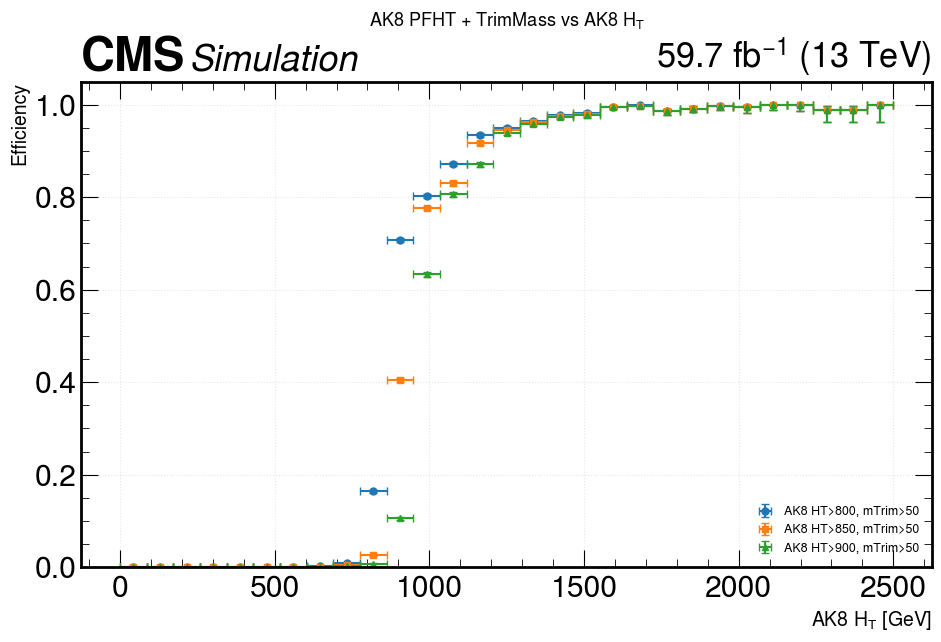

In [11]:
plot_eff(boosted_ak8ht, "ak8_ht",
         r'AK8 $H_T$ [GeV]',
         r'AK8 PFHT + TrimMass vs AK8 $H_T$', lbl_ak8ht)

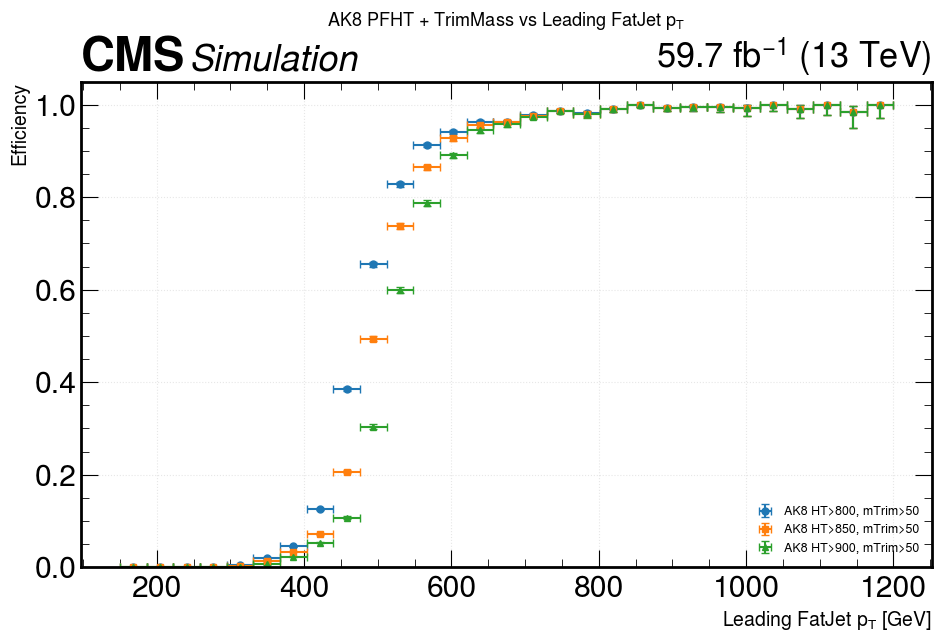

In [12]:
plot_eff(boosted_ak8ht, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'AK8 PFHT + TrimMass vs Leading FatJet $p_T$', lbl_ak8ht)

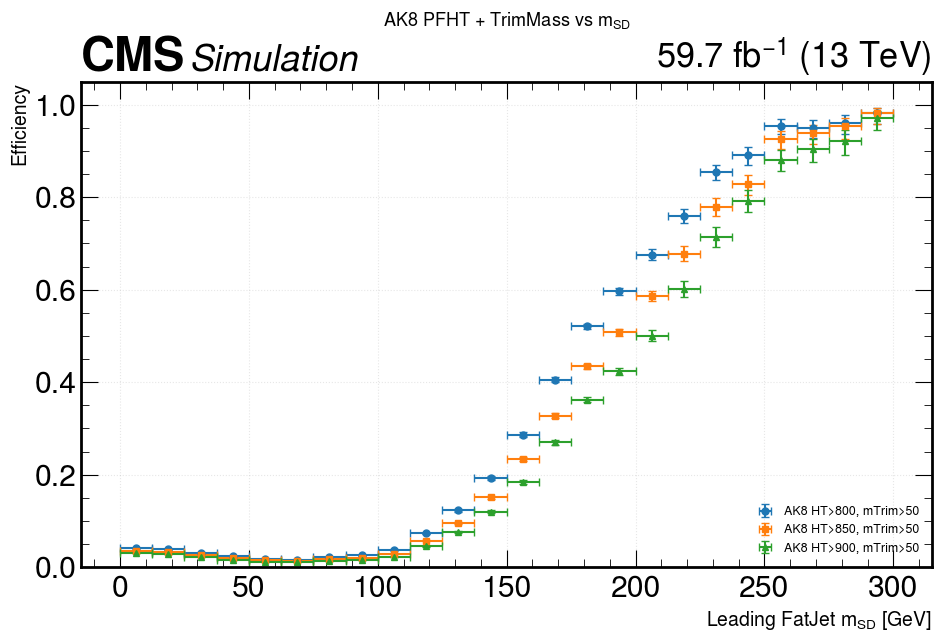

In [13]:
plot_eff(boosted_ak8ht, "lead_fj_msd",
         r'Leading FatJet $m_{SD}$ [GeV]',
         r'AK8 PFHT + TrimMass vs $m_{SD}$', lbl_ak8ht)

## 11. AK8 single jet + TrimMass
Single fat jet pT threshold with trimmed mass > 30 GeV.

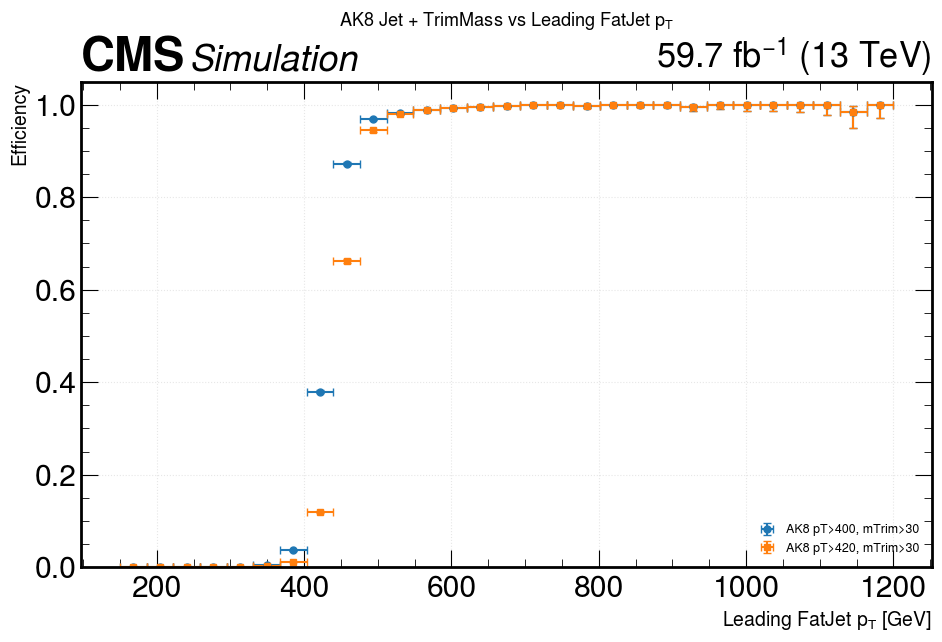

In [14]:
plot_eff(boosted_ak8jet_trim, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'AK8 Jet + TrimMass vs Leading FatJet $p_T$', lbl_ak8jet)

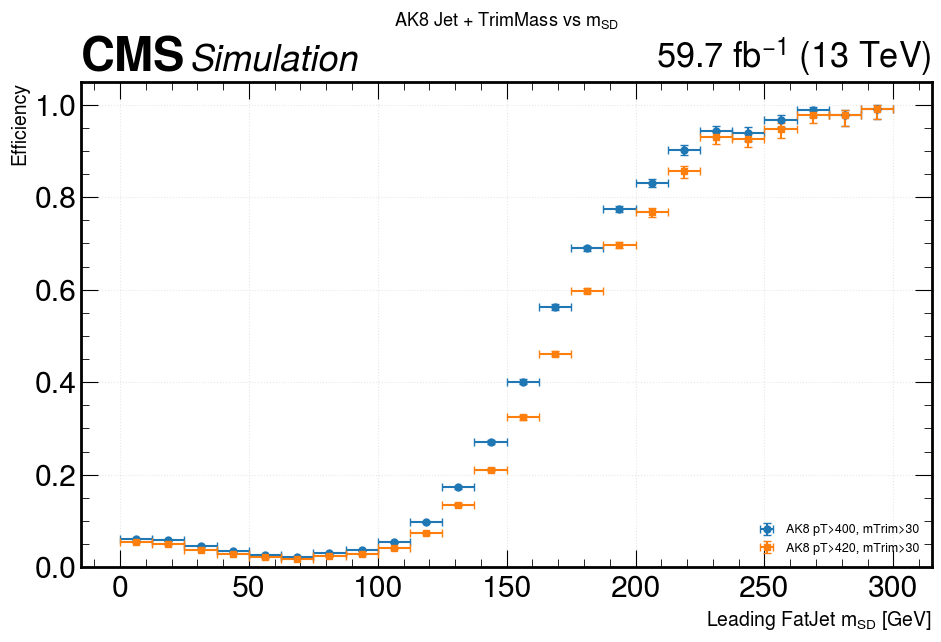

In [15]:
plot_eff(boosted_ak8jet_trim, "lead_fj_msd",
         r'Leading FatJet $m_{SD}$ [GeV]',
         r'AK8 Jet + TrimMass vs $m_{SD}$', lbl_ak8jet)

## 12. AK8 pure high-pT
No mass cut, just jet pT threshold.

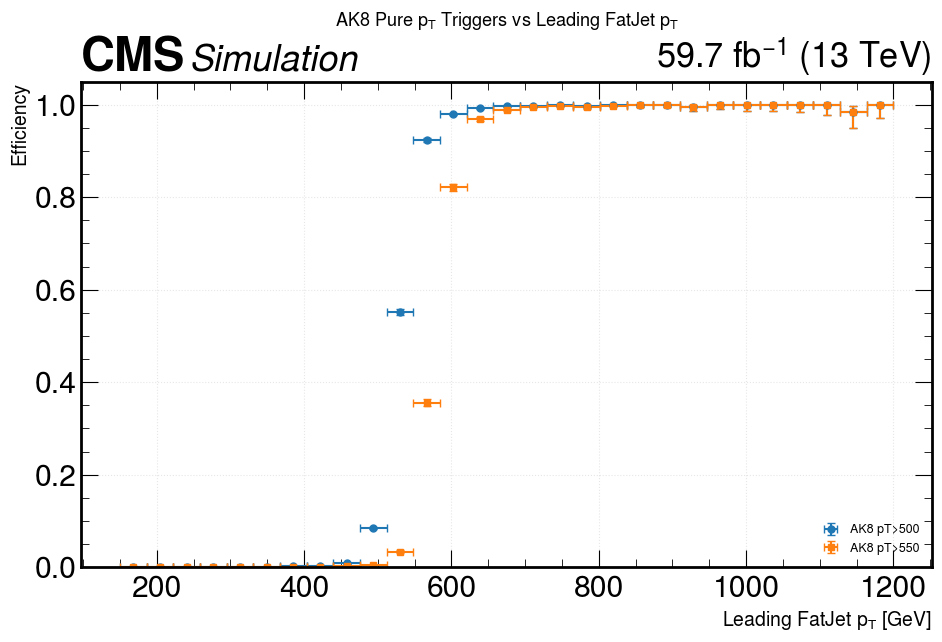

In [16]:
plot_eff(boosted_ak8jet_pt, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'AK8 Pure $p_T$ Triggers vs Leading FatJet $p_T$', lbl_ak8jet)

## 13. AK8 + b-tag
AK8 jet pT > 330 + trimmed mass > 30 + b-tagging (DeepCSV or BoostedDoubleB).

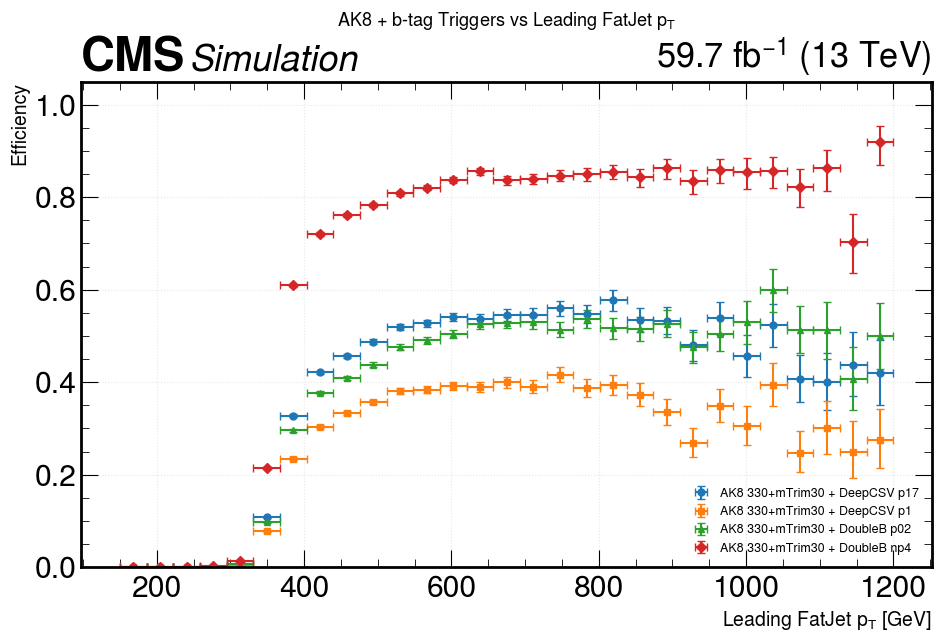

In [17]:
plot_eff(boosted_ak8_btag, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'AK8 + b-tag Triggers vs Leading FatJet $p_T$', lbl_ak8btag)

## 14. SixPFJet triggers (resolved)
6 AK4 jets + HT threshold, with optional b-tag.

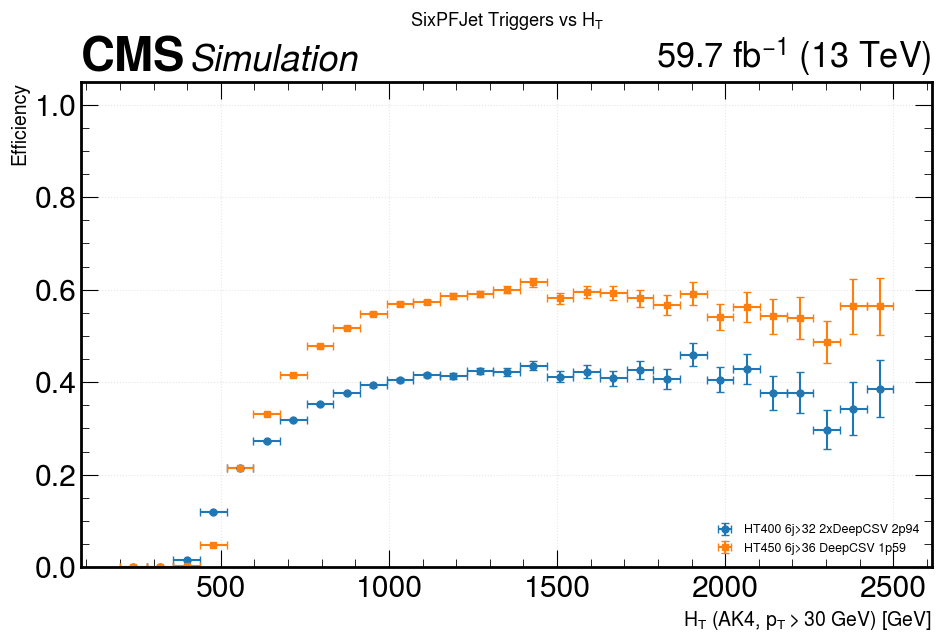

In [18]:
plot_eff(resolved_sixjet, "ht",
         r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
         r'SixPFJet Triggers vs $H_T$', lbl_sixjet)

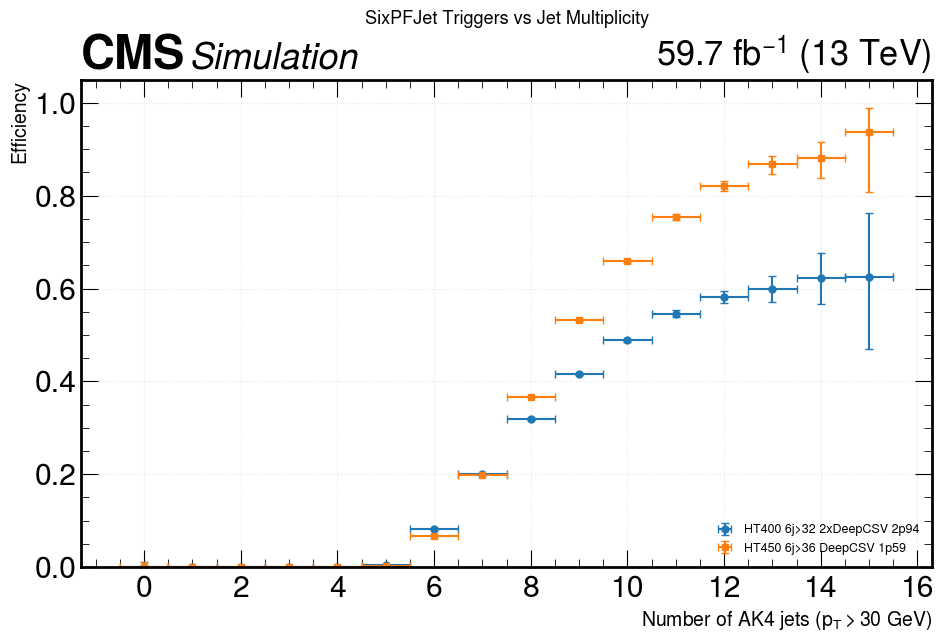

In [19]:
plot_eff(resolved_sixjet, "njet",
         r'Number of AK4 jets ($p_T > 30$ GeV)',
         r'SixPFJet Triggers vs Jet Multiplicity', lbl_sixjet)

## 15. QuadPFJet triggers (resolved)
4-jet topology, split into no-btag and btag variants.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


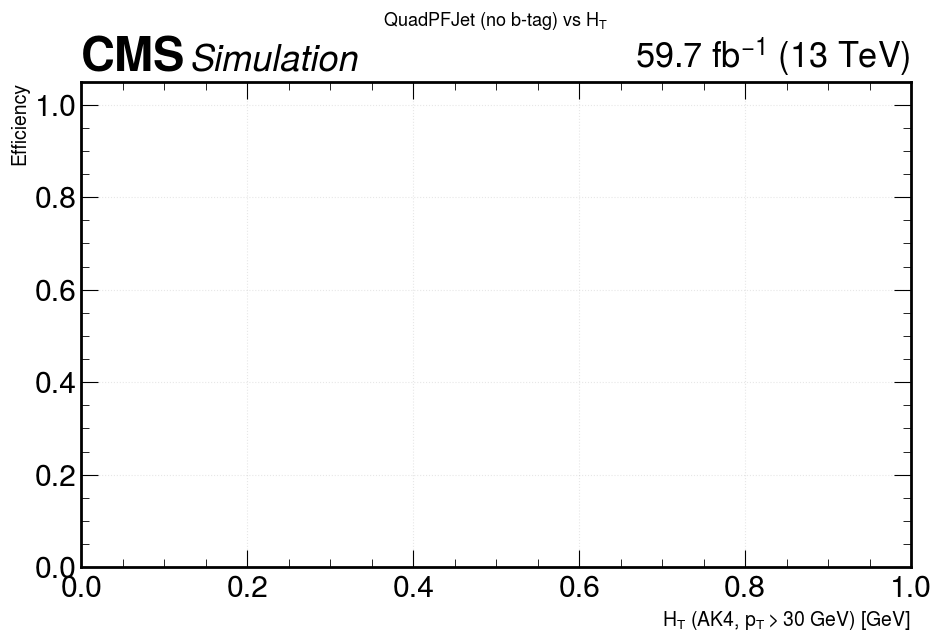

In [20]:
quad_nobtag = [t for t in resolved_quadjet if "BTag" not in t]
plot_eff(quad_nobtag, "ht",
         r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
         r'QuadPFJet (no b-tag) vs $H_T$', lbl_quad)

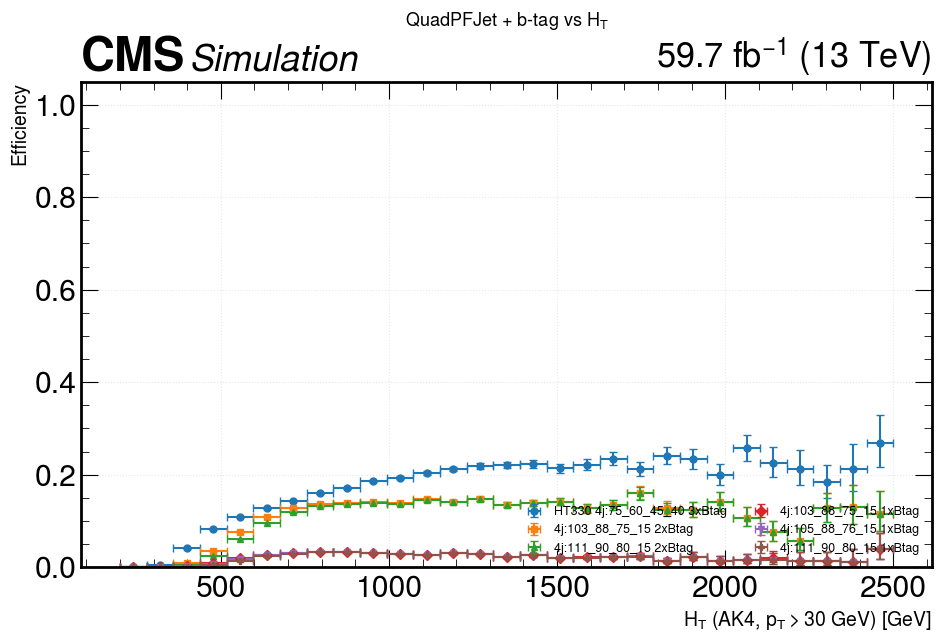

In [21]:
quad_btag = [t for t in resolved_quadjet if "BTag" in t]
plot_eff(quad_btag, "ht",
         r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
         r'QuadPFJet + b-tag vs $H_T$', lbl_quad, ncol=2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


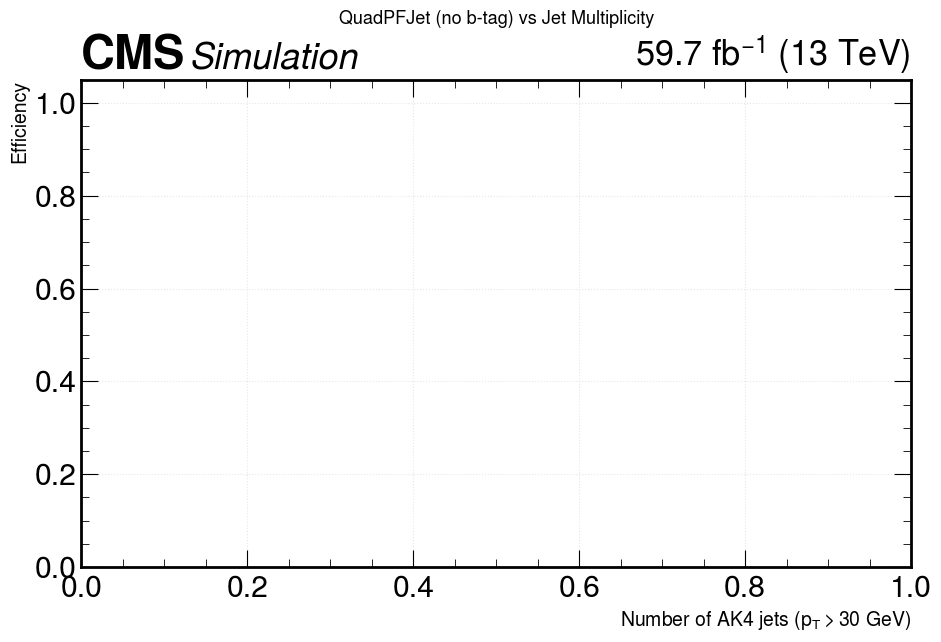

In [22]:
plot_eff(quad_nobtag, "njet",
         r'Number of AK4 jets ($p_T > 30$ GeV)',
         r'QuadPFJet (no b-tag) vs Jet Multiplicity', lbl_quad)

## 16. Inclusive PFHT triggers
Pure HT thresholds — useful as reference and backup.

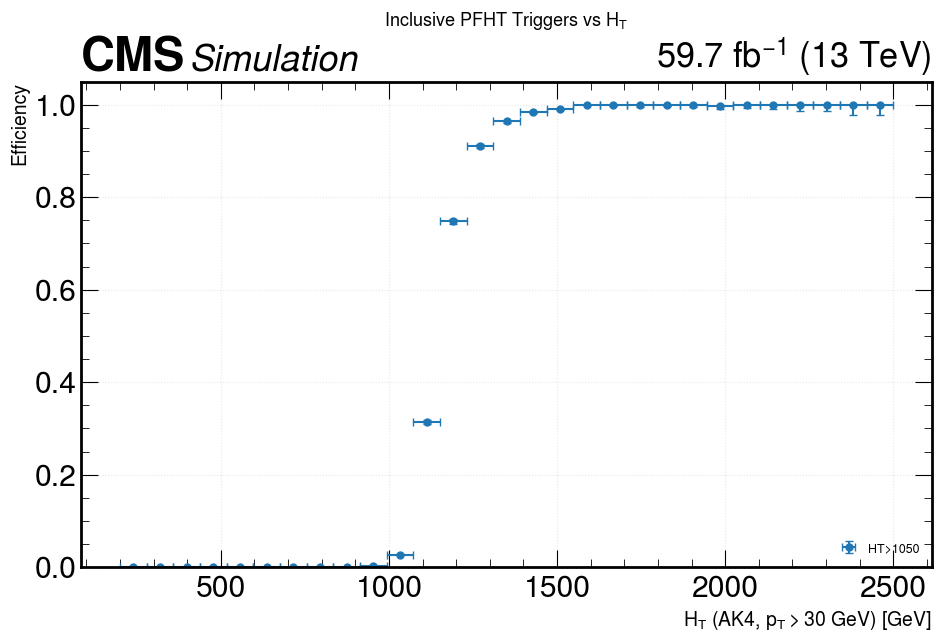

In [23]:
plot_eff(inclusive_pfht, "ht",
         r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]',
         r'Inclusive PFHT Triggers vs $H_T$', lbl_pfht)

## 17. Best from each boosted group
One representative trigger per AK8 category, overlaid.

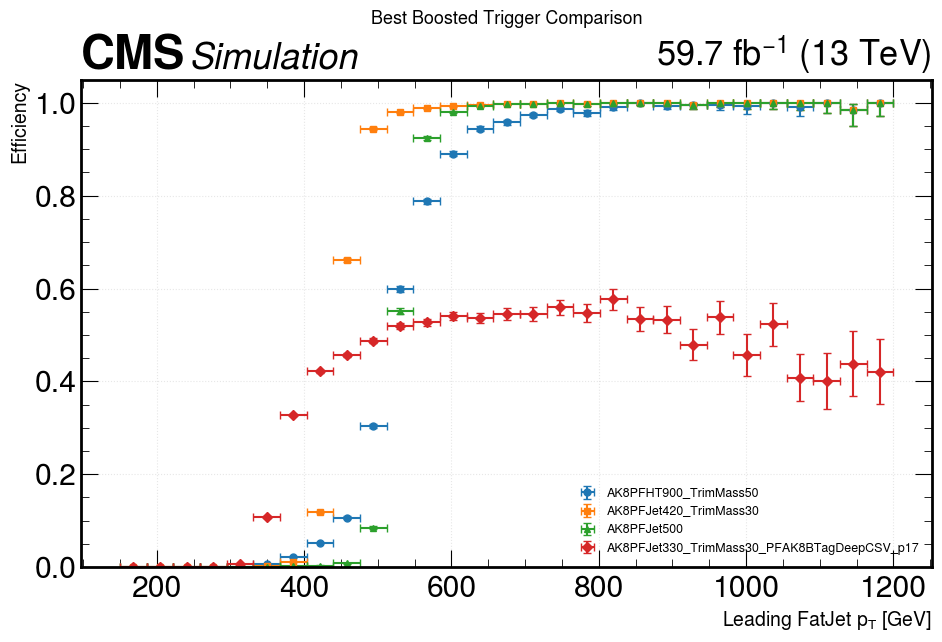

In [24]:
best = []
if boosted_ak8ht: best.append(boosted_ak8ht[-1])
if boosted_ak8jet_trim: best.append(boosted_ak8jet_trim[-1])
if boosted_ak8jet_pt: best.append(boosted_ak8jet_pt[0])
if boosted_ak8_btag: best.append(boosted_ak8_btag[0])

plot_eff(best, "lead_fj_pt",
         r'Leading FatJet $p_T$ [GeV]',
         r'Best Boosted Trigger Comparison', lbl_short)

---
## 18. OR trigger efficiencies
Combined efficiency — this is what actually matters for the analysis.

In [25]:
def make_or(trig_list):
    mask = np.zeros(N, dtype=bool)
    for t in trig_list:
        mask |= ak.to_numpy(data[t]).astype(bool)
    return mask

m_bst_ht = make_or(boosted_ak8ht)
m_bst_jet = make_or(boosted_ak8jet_trim)
m_bst_pt = make_or(boosted_ak8jet_pt)
m_bst_btag = make_or(boosted_ak8_btag)
m_all_bst = m_bst_ht | m_bst_jet | m_bst_pt | m_bst_btag

m_sixjet = make_or(resolved_sixjet)
m_quadjet = make_or(resolved_quadjet)
m_resolved = m_sixjet | m_quadjet

m_pfht = make_or(inclusive_pfht)
m_everything = m_all_bst | m_resolved | m_pfht

print("OR TRIGGER EFFICIENCIES")
print("=" * 50)
for label, mask in [
    ("OR(AK8 HT+TrimMass)", m_bst_ht),
    ("OR(AK8 Jet+TrimMass)", m_bst_jet),
    ("OR(AK8 pure pT)", m_bst_pt),
    ("OR(AK8 b-tag)", m_bst_btag),
    ("OR(ALL boosted AK8)", m_all_bst),
    ("OR(SixPFJet)", m_sixjet),
    ("OR(QuadPFJet)", m_quadjet),
    ("OR(ALL resolved)", m_resolved),
    ("OR(PFHT)", m_pfht),
    ("OR(EVERYTHING)", m_everything),
]:
    p = int(np.sum(mask))
    print(f"  {label}: {p}/{N} = {100*p/N:.1f}%")

OR TRIGGER EFFICIENCIES
  OR(AK8 HT+TrimMass): 36684/3194000 = 1.1%
  OR(AK8 Jet+TrimMass): 50769/3194000 = 1.6%
  OR(AK8 pure pT): 21138/3194000 = 0.7%
  OR(AK8 b-tag): 76527/3194000 = 2.4%
  OR(ALL boosted AK8): 86444/3194000 = 2.7%
  OR(SixPFJet): 304674/3194000 = 9.5%
  OR(QuadPFJet): 209725/3194000 = 6.6%
  OR(ALL resolved): 416257/3194000 = 13.0%
  OR(PFHT): 27178/3194000 = 0.9%
  OR(EVERYTHING): 454794/3194000 = 14.2%


## 19. OR efficiency vs leading FatJet pT
The key plot — how much signal we keep as a function of fat jet pT.

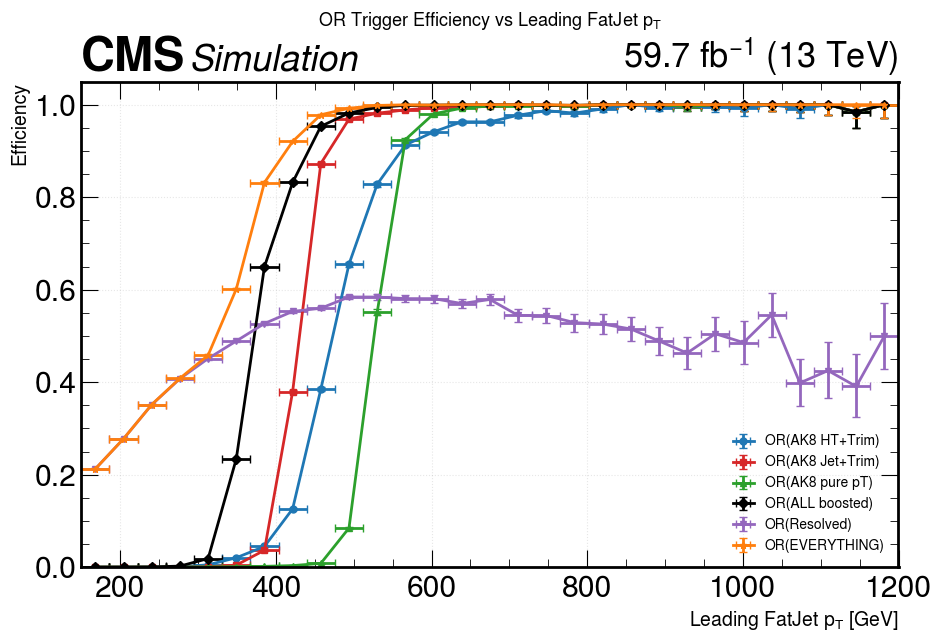

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

or_curves = [
    ("OR(AK8 HT+Trim)", m_bst_ht, 'tab:blue', 'o'),
    ("OR(AK8 Jet+Trim)", m_bst_jet, 'tab:red', 's'),
    ("OR(AK8 pure pT)", m_bst_pt, 'tab:green', '^'),
    ("OR(ALL boosted)", m_all_bst, 'black', 'D'),
    ("OR(Resolved)", m_resolved, 'tab:purple', 'v'),
    ("OR(EVERYTHING)", m_everything, 'tab:orange', '*'),
]

for label, mask, color, marker in or_curves:
    x, xw, eff, elo, ehi = calc_eff(mask[has_fj_np], lead_fj_pt, pt_bins)
    ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                fmt=f'-{marker}', color=color, capsize=3, markersize=5,
                linewidth=2, label=label)

ax.set_ylim(0, 1.05)
ax.set_xlim(150, 1200)
ax.set_xlabel(r'Leading FatJet $p_T$ [GeV]', fontsize=14)
ax.set_ylabel('Efficiency', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
hep.cms.text('Simulation', ax=ax)
hep.cms.lumitext(LUMI_TEXT, ax=ax)
ax.set_title(r'OR Trigger Efficiency vs Leading FatJet $p_T$', fontsize=13, pad=40)
plt.tight_layout()
plt.show()

## 20. OR efficiency vs AK4 HT

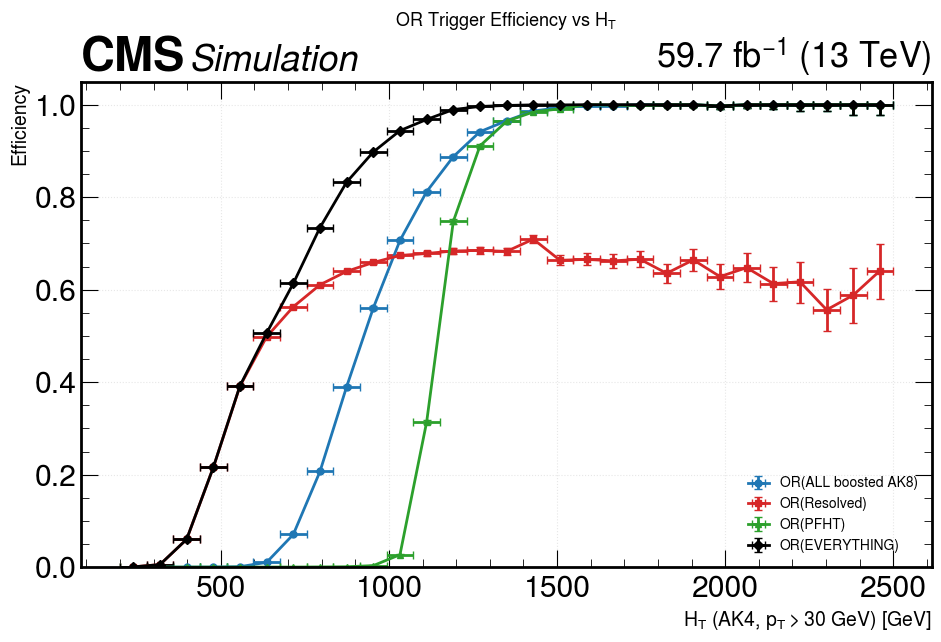

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

or_ht = [
    ("OR(ALL boosted AK8)", m_all_bst, 'tab:blue', 'o'),
    ("OR(Resolved)", m_resolved, 'tab:red', 's'),
    ("OR(PFHT)", m_pfht, 'tab:green', '^'),
    ("OR(EVERYTHING)", m_everything, 'black', 'D'),
]

for label, mask, color, marker in or_ht:
    x, xw, eff, elo, ehi = calc_eff(mask, ht, ht_bins)
    ax.errorbar(x, eff, xerr=xw, yerr=[elo, ehi],
                fmt=f'-{marker}', color=color, capsize=3, markersize=5,
                linewidth=2, label=label)

ax.set_ylim(0, 1.05)
ax.set_xlabel(r'$H_T$ (AK4, $p_T > 30$ GeV) [GeV]', fontsize=14)
ax.set_ylabel('Efficiency', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
hep.cms.text('Simulation', ax=ax)
hep.cms.lumitext(LUMI_TEXT, ax=ax)
ax.set_title(r'OR Trigger Efficiency vs $H_T$', fontsize=13, pad=40)
plt.tight_layout()
plt.show()

## 21. Full summary table

In [28]:
print(f"{'Trigger':<65} {'Passed':>8} {'Total':>8} {'Eff':>7}")
print("=" * 90)
for group_name, group_list in all_groups:
    if not group_list:
        continue
    print(f"\n--- {group_name} ---")
    for trig in group_list:
        p, t, f = overall[trig]
        print(f"  {trig:<63} {p:>8} {t:>8} {100*f:>6.1f}%")

Trigger                                                             Passed    Total     Eff

--- Boosted AK8 HT+TrimMass ---
  HLT_AK8PFHT800_TrimMass50                                          36684  3194000    1.1%
  HLT_AK8PFHT850_TrimMass50                                          30367  3194000    1.0%
  HLT_AK8PFHT900_TrimMass50                                          25149  3194000    0.8%

--- Boosted AK8 Jet+TrimMass ---
  HLT_AK8PFJet400_TrimMass30                                         50769  3194000    1.6%
  HLT_AK8PFJet420_TrimMass30                                         42331  3194000    1.3%

--- Boosted AK8 Jet pure pT ---
  HLT_AK8PFJet500                                                    21138  3194000    0.7%
  HLT_AK8PFJet550                                                    13979  3194000    0.4%

--- Boosted AK8 + b-tag ---
  HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepCSV_p17                    43319  3194000    1.4%
  HLT_AK8PFJet330_TrimMass30_PFAK8BTagDeepC